<a href="https://colab.research.google.com/github/tejas883/Roll_No_32_Machine-Learning-Lab/blob/main/ML_Experiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name :Tejas Surendra Mule

Batch :CS2


Roll Number :CS32



### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [ ]:

# Task 1: Import Libraries and Load Dataset

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import networkx as nx

from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Upload dataset manually
uploaded = files.upload()

# Read the uploaded CSV file
file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

# Display first five rows
print("First five rows of the dataset:")
print(df.head())

# Display dataset shape
print("\nDataset shape:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display dataset information
print("\nDataset information:")
df.info()

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

Saving archive (8).zip to archive (8).zip
First five rows of the dataset:
   Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0           1         13.540           14.36             87.46        566.3   
1           2         13.080           15.71             85.63        520.0   
2           3          9.504           12.44             60.34        273.9   
3           4         13.030           18.42             82.61        523.8   
4           5          8.196           16.84             51.71        201.9   

   x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
0            0.09779             0.08129           0.06664   
1            0.10750             0.12700           0.04568   
2            0.10240             0.06492           0.02956   
3            0.08983             0.03766           0.02562   
4            0.08600             0.05943           0.01588   

   x.concave_pts_mean  x.symmetry_mean  ...  x.texture_worst  \
0            0

# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

In [ ]:

# Task 2: Explore the Dataset

# 1. Display dataset dimensions
print("Dataset Dimensions:")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# 2. Display first five rows
print("\nFirst five rows:")
print(df.head())

# 3. Check missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

# 4. Display summary statistics
print("\nSummary Statistics:")
print(df.describe())

# 5. Display data types
print("\nFeature Data Types:")
print(df.dtypes)

# 6. Check diagnosis class distribution
# Supports common Kaggle column names: diagnosis or target
diagnosis_col = next(
    (col for col in df.columns
     if col.lower() in ["diagnosis", "target"]),
    None
)

if diagnosis_col is not None:
    print("\nDiagnosis Class Distribution:")
    print(df[diagnosis_col].value_counts())

    print("\nDiagnosis Class Percentage:")
    print(
        df[diagnosis_col].value_counts(normalize=True).mul(100).round(2)
    )

    # Plot diagnosis distribution
    df[diagnosis_col].value_counts().plot(
        kind="bar",
        color=["salmon", "skyblue"],
        edgecolor="black"
    )
    plt.title("Diagnosis Class Distribution")
    plt.xlabel("Diagnosis")
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("\nDiagnosis column not found.")
    print("Please check the column names displayed above.")

Dataset Dimensions:
Number of rows: 569
Number of columns: 32

First five rows:
   Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0           1         13.540           14.36             87.46        566.3   
1           2         13.080           15.71             85.63        520.0   
2           3          9.504           12.44             60.34        273.9   
3           4         13.030           18.42             82.61        523.8   
4           5          8.196           16.84             51.71        201.9   

   x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
0            0.09779             0.08129           0.06664   
1            0.10750             0.12700           0.04568   
2            0.10240             0.06492           0.02956   
3            0.08983             0.03766           0.02562   
4            0.08600             0.05943           0.01588   

   x.concave_pts_mean  x.symmetry_mean  ...  x.texture_worst  \
0       

# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [ ]:

# Task 3: Preprocess and Scale Features

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Clean column names
df.columns = df.columns.str.strip()

# Remove non-informative columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed", case=False)]

# Separate features and target
X = df.drop(columns=["y"]).select_dtypes(include=[np.number])
y = df["y"].copy()

# Handle missing values
X = X.dropna(axis=1, how="all")
X = X.fillna(X.median())

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display results
print("Original feature dimensions:", X.shape)
print("Scaled feature dimensions:", X_scaled.shape)

print("\nFeature names:")
print(X.columns.tolist())

print("\nFirst five rows of scaled features:")
print(pd.DataFrame(X_scaled, columns=X.columns).head())

print("\nTarget class distribution:")
print(y.value_counts())

print("\nScaled feature means (approximately 0):")
print(np.round(X_scaled.mean(axis=0)[:5], 4))

print("\nScaled feature standard deviations (approximately 1):")
print(np.round(X_scaled.std(axis=0)[:5], 4))

Original feature dimensions: (569, 30)
Scaled feature dimensions: (569, 30)

Feature names:
['x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se', 'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 'x.fractal_dim_worst']

First five rows of scaled features:
   x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0      -0.166799       -1.147162         -0.185728    -0.251957   
1      -0.297446       -0.833008         -0.261106    -0.383638   
2      -1.313080       -1.593959         -1.302806    -1.083572   
3      -0.311646       -

# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

Distance matrix shape: (569, 569)

First 5 x 5 distances:
[[0.   3.11 3.62 5.2  4.47]
 [3.11 0.   4.01 5.62 4.37]
 [3.62 4.01 0.   5.12 2.95]
 [5.2  5.62 5.12 0.   5.03]
 [4.47 4.37 2.95 5.03 0.  ]]

Number of nodes: 569
Number of edges: 161596
Is graph connected? True

Example edge (0, 1):
Euclidean distance: 3.1072466763624185


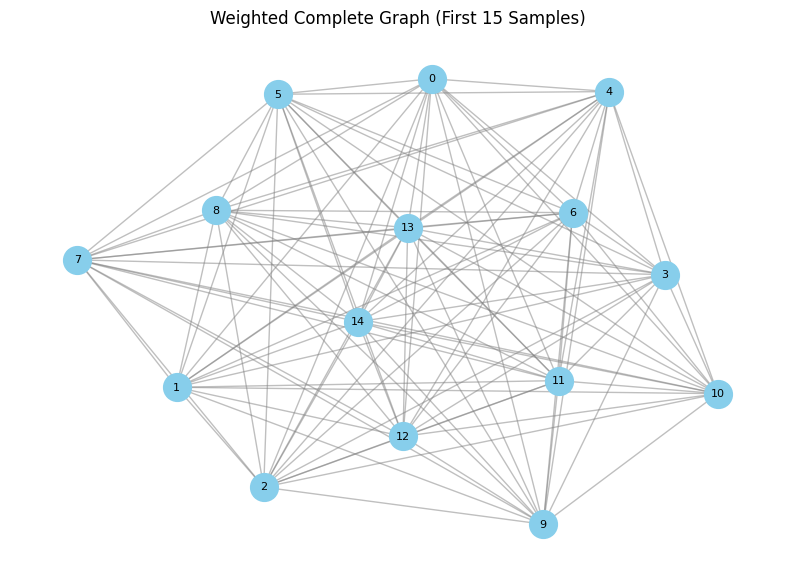

In [ ]:

# Task 4: Construct Pairwise Distance Matrix & Graph

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.spatial.distance import pdist, squareform

# 1. Compute pairwise Euclidean distances
distance_condensed = pdist(X_scaled, metric="euclidean")

# Convert condensed distances into a square distance matrix
distance_matrix = squareform(distance_condensed)

print("Distance matrix shape:", distance_matrix.shape)
print("\nFirst 5 x 5 distances:")
print(np.round(distance_matrix[:5, :5], 2))

# 2. Construct a weighted complete graph
G = nx.Graph()

# Add each sample as a node
n_samples = X_scaled.shape[0]
G.add_nodes_from(range(n_samples))

# Add weighted edges between every pair of samples
for i in range(n_samples):
    for j in range(i + 1, n_samples):
        G.add_edge(
            i,
            j,
            weight=float(distance_matrix[i, j])
        )

# 3. Display graph information
print("\nNumber of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is graph connected?", nx.is_connected(G))

# Display one example edge
print("\nExample edge (0, 1):")
print("Euclidean distance:", G[0][1]["weight"])

# 4. Visualize a small subgraph for clarity
# Showing all 569 nodes would make the graph difficult to read
sample_nodes = list(range(15))
G_small = G.subgraph(sample_nodes)

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G_small, seed=42)

nx.draw_networkx_nodes(
    G_small, pos,
    node_size=400,
    node_color="skyblue"
)
nx.draw_networkx_edges(
    G_small, pos,
    edge_color="gray",
    alpha=0.5
)
nx.draw_networkx_labels(G_small, pos, font_size=8)

plt.title("Weighted Complete Graph (First 15 Samples)")
plt.axis("off")
plt.show()

# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

Number of nodes in MST: 569
Number of edges in MST: 568
Is MST connected? True
Is MST acyclic? True

First 10 MST edges and weights:
   Source  Target    Weight
0       0      81  1.688590
1       0     108  2.171448
2       1     105  1.660727
3       2      70  2.218949
4       3     170  2.346213
5       3     222  2.541524
6       4     279  1.860324
7       4      84  2.166020
8       5     125  1.765873
9       5     172  2.017100

Total MST weight: 1393.8521

MST edge weight statistics:
count    568.000000
mean       2.453965
std        1.215837
min        1.006115
25%        1.722060
50%        2.147547
75%        2.779372
max       12.299945
Name: Weight, dtype: float64


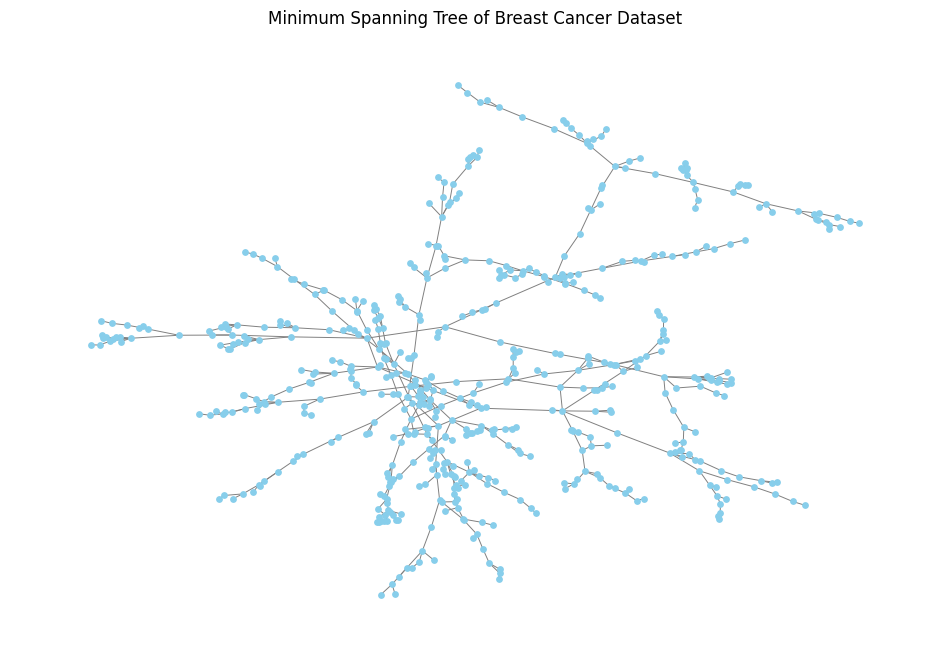

In [ ]:

# Task 5: Compute the Minimum Spanning Tree (MST)

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# 1. Compute the MST using NetworkX
MST = nx.minimum_spanning_tree(G, weight="weight", algorithm="kruskal")

# 2. Extract MST edges and weights
mst_edges = list(MST.edges(data=True))

# Create a DataFrame of MST connections
mst_df = pd.DataFrame([
    {
        "Source": u,
        "Target": v,
        "Weight": attributes["weight"]
    }
    for u, v, attributes in mst_edges
])

# 3. Display MST information
print("Number of nodes in MST:", MST.number_of_nodes())
print("Number of edges in MST:", MST.number_of_edges())
print("Is MST connected?", nx.is_connected(MST))
print("Is MST acyclic?", nx.is_forest(MST))

print("\nFirst 10 MST edges and weights:")
print(mst_df.head(10))

print("\nTotal MST weight:", round(MST.size(weight="weight"), 4))

# 4. Display edge weight statistics
print("\nMST edge weight statistics:")
print(mst_df["Weight"].describe())

# 5. Visualize the MST
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(MST, seed=42, weight="weight")

nx.draw_networkx_nodes(
    MST, pos,
    node_size=15,
    node_color="skyblue"
)

nx.draw_networkx_edges(
    MST, pos,
    edge_color="gray",
    width=0.7
)

plt.title("Minimum Spanning Tree of Breast Cancer Dataset")
plt.axis("off")
plt.show()

# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [ ]:

# Task 6: Implement Graph-Based Clustering (K=2)

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# Number of clusters
K = 2

# 1. Sort MST edges in descending order by weight
sorted_edges = sorted(
    MST.edges(data=True),
    key=lambda edge: edge[2]["weight"],
    reverse=True
)

print("Top 10 largest MST edges:")
for u, v, data in sorted_edges[:10]:
    print(f"Edge ({u}, {v}) - Weight: {data['weight']:.4f}")

# 2. Copy MST and remove the largest K-1 edges
cluster_graph = MST.copy()

largest_edges = sorted_edges[:K - 1]

for u, v, data in largest_edges:
    cluster_graph.remove_edge(u, v)
    print(
        f"\nRemoved edge ({u}, {v}) "
        f"with weight {data['weight']:.4f}"
    )

# 3. Find connected components
components = list(nx.connected_components(cluster_graph))

print("\nNumber of clusters formed:", len(components))

# 4. Assign cluster labels to each sample
cluster_labels = [0] * X_scaled.shape[0]

for cluster_id, component in enumerate(components):
    for node in component:
        cluster_labels[node] = cluster_id

# Store cluster labels
df["Cluster"] = cluster_labels

# 5. Display cluster sizes
print("\nCluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())

print("\nFirst 10 samples with cluster labels:")
print(df[["y", "Cluster"]].head(10))

# 6. Verify number of clusters
assert len(components) == K, "Expected exactly 2 clusters"

print("\nClustering completed successfully!")

Top 10 largest MST edges:
Edge (544, 553) - Weight: 12.2999
Edge (18, 69) - Weight: 10.4761
Edge (48, 468) - Weight: 8.8264
Edge (467, 544) - Weight: 8.2685
Edge (424, 429) - Weight: 8.0780
Edge (360, 454) - Weight: 7.8710
Edge (18, 208) - Weight: 7.7911
Edge (412, 515) - Weight: 7.0895
Edge (454, 515) - Weight: 7.0626
Edge (369, 395) - Weight: 6.9690

Removed edge (544, 553) with weight 12.2999

Number of clusters formed: 2

Cluster sizes:
0    567
1      2
Name: count, dtype: int64

First 10 samples with cluster labels:
   y  Cluster
0  B        0
1  B        0
2  B        0
3  B        0
4  B        0
5  B        0
6  B        0
7  B        0
8  B        0
9  B        0

Clustering completed successfully!


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [ ]:

# Task 7: Evaluate MST Clustering Performance

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)
import numpy as np
import pandas as pd

# 1. Ground truth labels
# y contains the actual diagnosis labels
true_labels = y

# 2. Predicted cluster labels from Task 6
predicted_clusters = np.array(cluster_labels)

# Convert actual diagnosis labels into numeric values if needed
true_labels_numeric = pd.factorize(true_labels)[0]

# 3. Calculate Silhouette Score using scaled features
sil_score = silhouette_score(
    X_scaled,
    predicted_clusters,
    metric="euclidean"
)

# 4. Calculate Adjusted Rand Index (ARI)
ari = adjusted_rand_score(
    true_labels_numeric,
    predicted_clusters
)

# 5. Calculate Normalized Mutual Information (NMI)
nmi = normalized_mutual_info_score(
    true_labels_numeric,
    predicted_clusters
)

# 6. Display evaluation results
print("MST Clustering Evaluation Results")
print("---------------------------------")
print(f"Silhouette Score: {sil_score:.4f}")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

MST Clustering Evaluation Results
---------------------------------
Silhouette Score: 0.6607
Adjusted Rand Index (ARI): 0.0048
Normalized Mutual Information (NMI): 0.0102


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

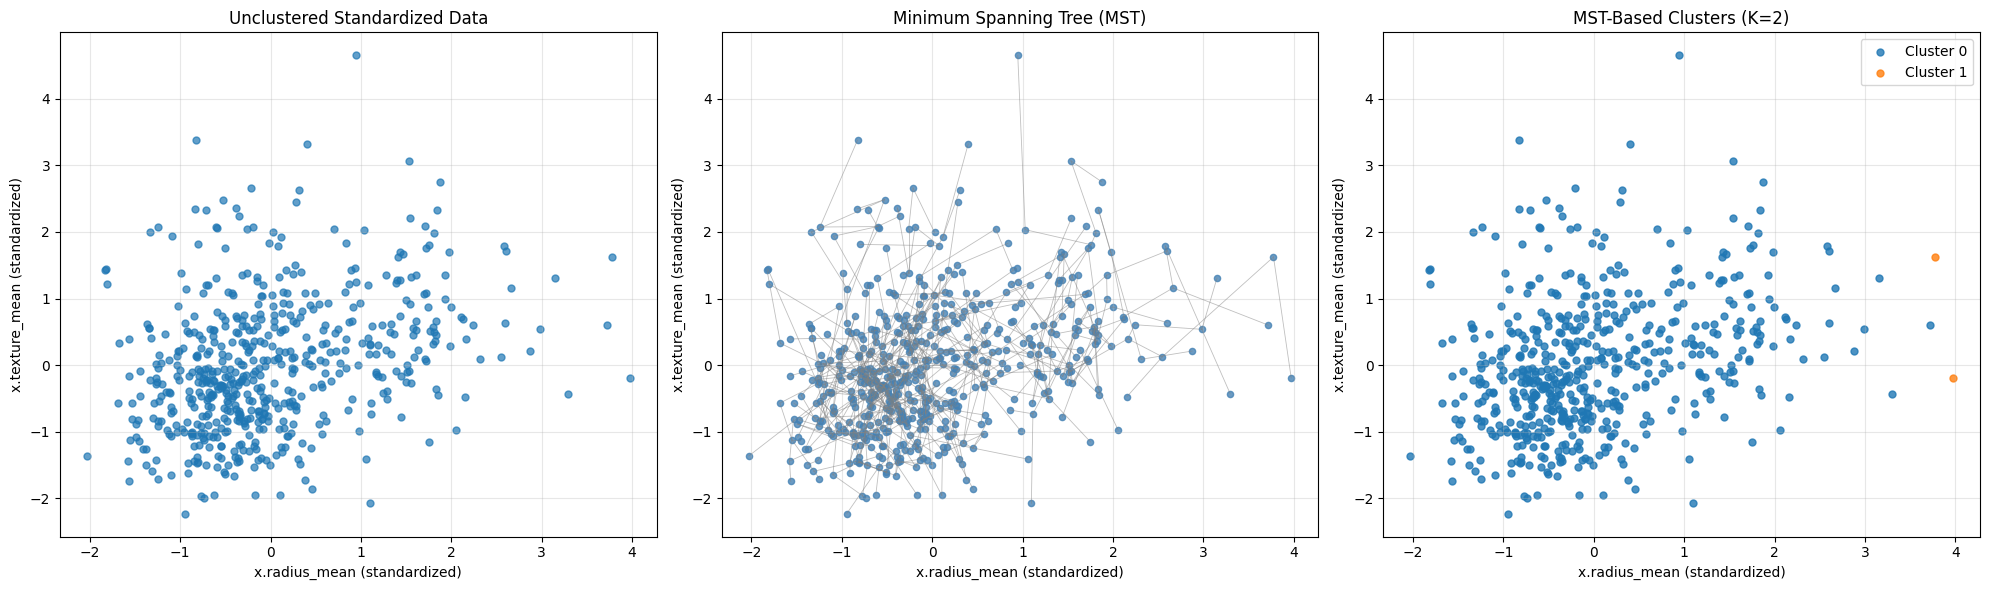

In [ ]:

# Task 8: Visualize MST and Graph-Based Clusters

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# 1. Select two representative features
# Use the first two features: radius mean and texture mean
feature_names = list(X.columns)

feature1 = "x.radius_mean" if "x.radius_mean" in X.columns else feature_names[0]
feature2 = "x.texture_mean" if "x.texture_mean" in X.columns else feature_names[1]

idx1 = X.columns.get_loc(feature1)
idx2 = X.columns.get_loc(feature2)

# Extract standardized feature values
plot_data = X_scaled[:, [idx1, idx2]]

# Use labels from Task 6
clusters = np.array(cluster_labels)

# 2. Create three side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Unclustered standardized data
axes[0].scatter(
    plot_data[:, 0],
    plot_data[:, 1],
    s=25,
    alpha=0.7
)
axes[0].set_title("Unclustered Standardized Data")
axes[0].set_xlabel(f"{feature1} (standardized)")
axes[0].set_ylabel(f"{feature2} (standardized)")
axes[0].grid(alpha=0.3)

# Plot 2: MST edges overlaid on standardized data
axes[1].scatter(
    plot_data[:, 0],
    plot_data[:, 1],
    s=20,
    color="steelblue",
    alpha=0.8
)

for u, v in MST.edges():
    axes[1].plot(
        [plot_data[u, 0], plot_data[v, 0]],
        [plot_data[u, 1], plot_data[v, 1]],
        color="gray",
        linewidth=0.6,
        alpha=0.5
    )

axes[1].set_title("Minimum Spanning Tree (MST)")
axes[1].set_xlabel(f"{feature1} (standardized)")
axes[1].set_ylabel(f"{feature2} (standardized)")
axes[1].grid(alpha=0.3)

# Plot 3: Final clusters after cutting the largest MST edge
for cluster_id in np.unique(clusters):
    mask = clusters == cluster_id
    axes[2].scatter(
        plot_data[mask, 0],
        plot_data[mask, 1],
        s=25,
        alpha=0.8,
        label=f"Cluster {cluster_id}"
    )

axes[2].set_title("MST-Based Clusters (K=2)")
axes[2].set_xlabel(f"{feature1} (standardized)")
axes[2].set_ylabel(f"{feature2} (standardized)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.